<a href="https://colab.research.google.com/github/munawirmt/ANN-PREDICTION-MODEL/blob/main/ANN_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANN (ARITIFICIAL NEURAL NETWORK) LAYER MODEL CREATE AND PREDICT THE NEW DATA BYB TRAINING WITH CHURN_MODELLING DATASET**

In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 32.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tenso

In [1]:
!pip install "tensorflow>=2.20.0,<2.21.0" "protobuf<6.0.0dev,>=5.29.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.8/620.8 MB 772.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 27.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.2
    Uninstalling protobuf-7.36.2:
      Successfully uninstalled protobuf-7.36.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.21.0
    Uninstalling tensorflow-2.21.0:
      Successfully uninstalled tensorflow-2.21.0


In [2]:
import tensorflow as tf

In [3]:
print(tf.__version__)

2.20.0


In [4]:
## basic libreries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
## load dataset
from google.colab import drive
drive.mount('/content/drive')

file_path='/content/drive/My Drive/DEEP LEARNING/Churn_Modelling.csv'
data_set=pd.read_csv(file_path)
data_set

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
data_set.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
## devide dataset into dipendend and indipendent features
x=data_set.iloc[:,3:13]
y=data_set.iloc[:,13]

In [13]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [14]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [15]:
## feature engineering
geography=pd.get_dummies(x['Geography'],drop_first=True)
gender=pd.get_dummies(x['Gender'],drop_first=True)


In [16]:
x=x.drop(['Geography','Gender'],axis=1)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [17]:
## cancatinate these variables with dataframe
x=pd.concat([x,geography,gender],axis=1)

In [18]:
## splitting dataset into training and test datas
from sklearn.model_selection import train_test_split

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [20]:
## feature scalling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [21]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [22]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [23]:
x_train.shape

(8000, 11)

**ANN IMPLIMENTATION**

In [24]:
## create ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [25]:
classifier=Sequential()


In [26]:
## adding input layer
classifier.add(Dense(units=11,activation='relu'))

In [27]:
## adding first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

In [28]:
## adding second hidden layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

In [29]:
## adding output layer
classifier.add(Dense(units=1,activation='sigmoid'))


In [30]:
## compile by adding optimizer
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [31]:
import tensorflow

In [32]:
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [33]:
## train
## model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=100)

In [34]:
## add early stopping before training
import tensorflow as tf


In [35]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [36]:
## train after adding early stopping
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=100,callbacks=early_stopping)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7697 - loss: 0.5393 - val_accuracy: 0.7955 - val_loss: 0.4724
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7955 - loss: 0.4871 - val_accuracy: 0.7955 - val_loss: 0.4543
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7979 - loss: 0.4657 - val_accuracy: 0.7963 - val_loss: 0.4393
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8018 - loss: 0.4553 - val_accuracy: 0.7986 - val_loss: 0.4300
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8044 - loss: 0.4488 - val_accuracy: 0.8012 - val_loss: 0.4238
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8009 - loss: 0.4411 - val_accuracy: 0.8012 - val_loss: 0.4166
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8102 - loss: 0.4313 - val_accuracy: 0.8050 - val_loss: 0.4101
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8171 - loss: 0.4130 - val_accu

In [37]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

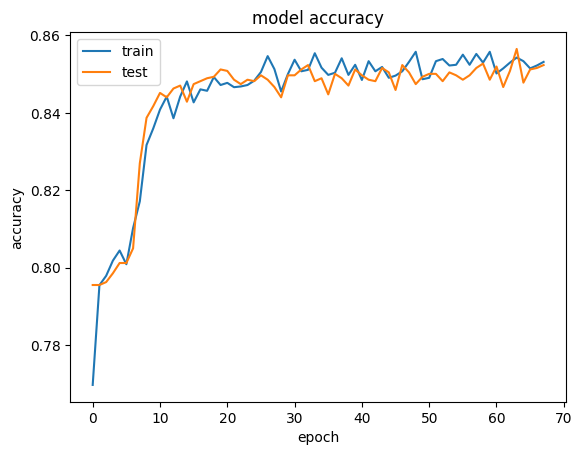

In [38]:
## plot summary for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

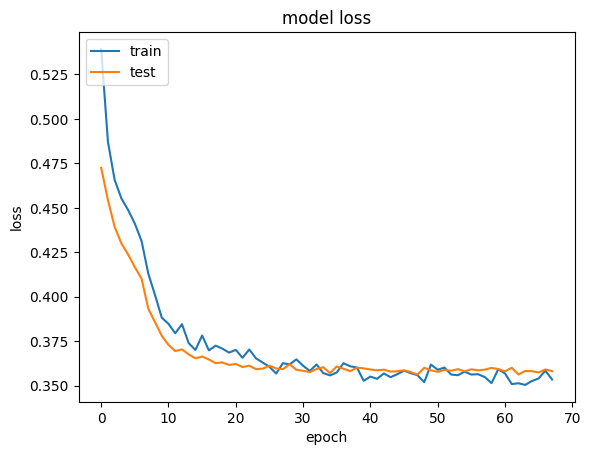

In [39]:
## summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

making predictions and evaluating **model**

In [40]:
## predicting test set results
y_pred=classifier.predict(x_test)
y_pred=(y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [41]:
## make confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1542,   53],
       [ 224,  181]])

In [42]:
## calculate accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.8615

In [43]:
## get the weights (to store it as pkl file for production deployment)
classifier.get_weights()

[array([[-8.19146112e-02,  1.67520687e-01,  1.00661471e-01,
          3.65664631e-01, -2.25325912e-01, -1.10017357e-03,
          3.19189906e-01, -5.06951176e-02,  9.90826637e-02,
          4.18684371e-02,  1.88159913e-01],
        [ 1.95316792e-01,  5.29534407e-02, -1.44134080e-02,
         -7.61518955e-01, -5.10908723e-01, -9.17771816e-01,
         -3.61076504e-01, -6.52034283e-01, -6.65781319e-01,
          1.37882769e-01,  5.05033314e-01],
        [-3.91052216e-01,  1.05560683e-02, -3.04145571e-02,
         -4.94147569e-01,  2.44428620e-01,  7.08201304e-02,
         -3.86977166e-01,  3.29275914e-02, -2.95214295e-01,
          7.82530308e-02,  7.56546482e-02],
        [-3.55193585e-01, -3.29464644e-01,  4.23778325e-01,
         -4.35656160e-01,  1.44788846e-01,  1.44174233e-01,
         -4.85651791e-01, -6.39302209e-02, -5.58594644e-01,
         -2.82817096e-01, -1.06632531e-01],
        [ 7.02543139e-01,  7.01908529e-01,  1.27237475e+00,
          3.51640433e-01,  2.07902774e-01,  